# Subgraph type 1: shared state (add it directly as a node)

The subgraph's state uses **the same keys** as the parent (`draft`, `final`), so the compiled
subgraph can be passed straight to `add_node`. LangGraph copies the shared keys in and out.

```
Parent:    START -> write_draft -> [ editor subgraph ] -> END
Subgraph:          START -> fix_grammar -> make_shorter -> END
```

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(model='openai/gpt-oss-20b', reasoning_effort='low')

In [2]:
# ---------- Subgraph: an 'editor' that improves any draft ----------
class EditorState(TypedDict):
    draft: str   # shared with the parent
    final: str   # shared with the parent
    fixed: str   # private: only the subgraph uses it


def fix_grammar(state: EditorState):
    return {'fixed': model.invoke(f"Fix grammar and spelling. Reply with only the text.\n{state['draft']}").content}


def make_shorter(state: EditorState):
    return {'final': model.invoke(f"Shorten this to 2 sentences. Reply with only the text.\n{state['fixed']}").content}


editor_builder = StateGraph(EditorState)
editor_builder.add_node('fix_grammar', fix_grammar)
editor_builder.add_node('make_shorter', make_shorter)
editor_builder.add_edge(START, 'fix_grammar')
editor_builder.add_edge('fix_grammar', 'make_shorter')
editor_builder.add_edge('make_shorter', END)

editor_subgraph = editor_builder.compile()

In [3]:
# ---------- Parent graph ----------
class ParentState(TypedDict):
    topic: str
    draft: str
    final: str


def write_draft(state: ParentState):
    # a deliberately messy draft, so the editor has something to fix
    prompt = f"Write 4 casual sentences about {state['topic']} with a few spelling mistakes. Reply with only the text."
    return {'draft': model.invoke(prompt).content}


parent_builder = StateGraph(ParentState)
parent_builder.add_node('write_draft', write_draft)
parent_builder.add_node('editor', editor_subgraph)  # <-- the compiled subgraph IS the node
parent_builder.add_edge(START, 'write_draft')
parent_builder.add_edge('write_draft', 'editor')
parent_builder.add_edge('editor', END)

workflow = parent_builder.compile()

In [4]:
result = workflow.invoke({'topic': 'learning to code'})

print('DRAFT:\n', result['draft'])
print('\nFINAL:\n', result['final'])
print('\nKeys in parent result:', list(result))  # 'fixed' is not here: it stayed inside the subgraph

DRAFT:
 Learning to code feels kinda like a puzzle, but i get more and more excited each day.  
I keep trynig to debug my mistakes and it actually makes me feel like a detective.  
Sometimes the syntax errors are super confusing, but i just keep practicing and it gets easier.  
Soon i hope to build my own app and share it with my friends, it feels like a cool project.

FINAL:
 Learning to code feels like a puzzle that excites me more each day, and debugging my mistakes makes me feel like a detective. I keep practicing through confusing syntax errors, hoping soon to build and share my own app with friends.

Keys in parent result: ['topic', 'draft', 'final']


In [5]:
# subgraphs=True streams updates from inside the subgraph too; the namespace says where they came from
for namespace, update in workflow.stream({'topic': 'drinking tea'}, stream_mode='updates', subgraphs=True):
    print(namespace or ('parent',), '->', list(update))

('parent',) -> ['write_draft']


('editor:b1b547db-4bed-5663-432d-254b5831acb7',) -> ['fix_grammar']


('editor:b1b547db-4bed-5663-432d-254b5831acb7',) -> ['make_shorter']
('parent',) -> ['editor']


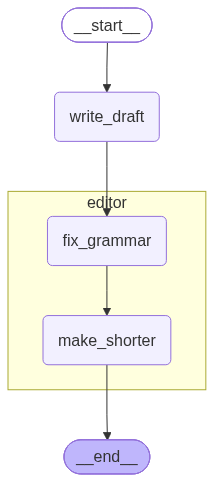

In [6]:
from IPython.display import Image
Image(workflow.get_graph(xray=True).draw_mermaid_png())  # xray=True also draws the inside of the subgraph